Vivian Hu and Duilio Lucio Project 1 Extension

We decided to do a binary classification on the Ionosphere dataset. Each example is a vector of  features 𝑥∈𝑅^M, here, M = 34. The label is either good (g) or bad (b) and it is converted into 1 or 0. the goal is to learn weights and bias so that the model predicts correctly. 


In [20]:
import numpy as np
from adaline_logistic import AdalineLogistic, AdalineGatedLogistic
from k_fold import kfold_cv

import numpy as np

data = np.genfromtxt("Data/ionosphere.csv", delimiter=",", dtype=str)

X = data[:, :-1].astype(float)
y = (data[:, -1] == "g").astype(int)   # g -> 1, b -> 0

print("Label counts:", np.unique(y, return_counts=True))
assert set(np.unique(y)) == {0, 1}, "Label parsing failed: y should contain both 0 and 1."

Label counts: (array([0, 1]), array([126, 225]))


In [21]:
# train / val split (80/20)
# shuffle indices so the split is random. Validation simulated "new data" and tells if generalizing

rng = np.random.default_rng(0)
idx = rng.permutation(len(X))
split = int(0.8 * len(X))
train_idx, val_idx = idx[:split], idx[split:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

# hyperparams
epochs = 1000
lr = 0.01
seed = 0

In [22]:
# baseline (single-layer logistic)
base = AdalineLogistic()
base.fit(X_train, y_train, n_epochs=epochs, lr=lr, r_seed=seed)
base_train_acc = base.accuracy(y_train, base.predict(X_train))
base_val_acc = base.accuracy(y_val, base.predict(X_val))
print("Baseline Logistic — train acc:", base_train_acc, "| val acc:", base_val_acc)

# extension (single-layer logistic + learnable gates)
gated = AdalineGatedLogistic(gate_init=0.0)
gated.fit(X_train, y_train, n_epochs=epochs, lr=lr, r_seed=seed, l1_gate=0.0)
g_train_acc = gated.accuracy(y_train, gated.predict(X_train))
g_val_acc = gated.accuracy(y_val, gated.predict(X_val))
print("Gated Logistic Extension — train acc:", g_train_acc, "| val acc:", g_val_acc)

# interpretability: top gated features
gates = gated.get_gates()
topk = 8
idx = np.argsort(-gates)[:topk]
print("Top gated feature indices (0-based):", idx.tolist())
print("Top gated values:", gates[idx].round(4).tolist())

Baseline Logistic — train acc: 0.8357142857142857 | val acc: 0.8873239436619719
Gated Logistic Extension — train acc: 0.75 | val acc: 0.8028169014084507
Top gated feature indices (0-based): [3, 1, 5, 29, 0, 6, 25, 21]
Top gated values: [0.5129, 0.512, 0.5095, 0.5048, 0.5044, 0.5033, 0.5023, 0.5022]


In [23]:
# Run CV on baseline logistic
acc_base = kfold_cv(
    X, y,
    model_class=AdalineLogistic,
    k=5,
    n_epochs=1000,
    lr=0.01,
    seed=0
)

print("Baseline Logistic:")
print("Mean acc:", acc_base.mean())
print("Std acc:", acc_base.std())
print("Folds:", acc_base)

Baseline Logistic:
Mean acc: 0.8917505030181087
Std acc: 0.03676734124795474
Folds: [0.88732394 0.92857143 0.88571429 0.82857143 0.92857143]


In [24]:
# Run CV on gated extension
acc_gated = kfold_cv(
    X, y,
    model_class=AdalineGatedLogistic,
    k=5,
    n_epochs=1000,
    lr=0.01,
    seed=0,
    gate_init=0.0
)

print("Gated Logistic:")
print("Mean acc:", acc_gated.mean())
print("Std acc:", acc_gated.std())
print("Folds:", acc_gated)

Gated Logistic:
Mean acc: 0.8717505030181087
Std acc: 0.02873915683907517
Folds: [0.88732394 0.87142857 0.85714286 0.82857143 0.91428571]


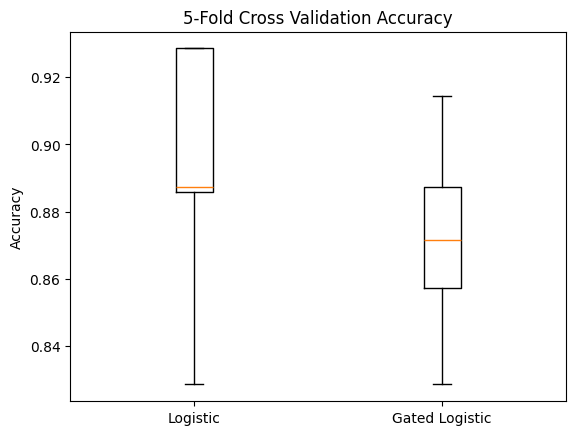

Logistic: mean = 0.8917505030181087 std = 0.03676734124795474
Gated Logistic: mean = 0.8717505030181087 std = 0.02873915683907517


In [26]:
import matplotlib.pyplot as plt

plt.boxplot([acc_base, acc_gated], labels=["Logistic", "Gated Logistic"])
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.show()
print("Logistic: mean =", acc_base.mean(), "std =", acc_base.std())
print("Gated Logistic: mean =", acc_gated.mean(), "std =", acc_gated.std())